## Ensamble Techniques For Regression


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Import Dataset

In [3]:
!wget https://raw.githubusercontent.com/itsNV/House-Price-Prediction/refs/heads/main/test.csv


!wget https://raw.githubusercontent.com/itsNV/House-Price-Prediction/refs/heads/main/train.csv

--2026-01-02 05:09:22--  https://raw.githubusercontent.com/itsNV/House-Price-Prediction/refs/heads/main/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5424551 (5.2M) [text/plain]
Saving to: ‘test.csv’

test.csv            100%[===================>]   5.17M  --.-KB/s    in 0.09s   

2026-01-02 05:09:22 (58.2 MB/s) - ‘test.csv’ saved [5424551/5424551]

--2026-01-02 05:09:22--  https://raw.githubusercontent.com/itsNV/House-Price-Prediction/refs/heads/main/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2480912 (2.

In [4]:

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [5]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


### Preprocessing

#### Missing Values

In [6]:
train.isnull().sum()

,0
POSTED_BY,0
UNDER_CONSTRUCTION,0
RERA,0
BHK_NO.,0
BHK_OR_RK,0
SQUARE_FT,0
READY_TO_MOVE,0
RESALE,0
ADDRESS,0
LONGITUDE,0


#### Duplicated values

In [7]:
train[train.duplicated() == 'True']

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)


#### Check for uniqueness

In [8]:
for i in train.columns:

  if(train[i].dtype == object):
    print(f'Uniqueness in {i} Column',train[i].unique())


Uniqueness in POSTED_BY Column ['Owner' 'Dealer' 'Builder']
Uniqueness in BHK_OR_RK Column ['BHK' 'RK']
Uniqueness in ADDRESS Column ['Ksfc Layout,Bangalore' 'Vishweshwara Nagar,Mysore' 'Jigani,Bangalore'
 ... 'west mambalam,Chennai' 'Gandhi Nagar,Gulbarga'
 'E3-108, Lake View Recidency,,Vapi']


#### Cnverting Categorical columns to numerical columns

In [9]:
from sklearn.preprocessing import LabelEncoder


def cat_to_num(dataframe):

  for i in dataframe.columns:

    if(dataframe[i].dtype == object):

      le = LabelEncoder()
      dataframe[i] = le.fit_transform(dataframe[i])

  return dataframe





In [10]:
train_updated = cat_to_num(train)
test_updated = cat_to_num(test)
train.head(),test.head()

(   POSTED_BY  UNDER_CONSTRUCTION  RERA  BHK_NO.  BHK_OR_RK    SQUARE_FT  \
 0          2                   0     0        2          0  1300.236407   
 1          1                   0     0        2          0  1275.000000   
 2          2                   0     0        2          0   933.159722   
 3          2                   0     1        2          0   929.921143   
 4          1                   1     0        2          0   999.009247   
 
    READY_TO_MOVE  RESALE  ADDRESS  LONGITUDE   LATITUDE  TARGET(PRICE_IN_LACS)  
 0              1       1     2844  12.969910  77.597960                   55.0  
 1              1       1     6576  12.274538  76.644605                   51.0  
 2              1       1     2256  12.778033  77.632191                   43.0  
 3              1       1     5095  28.642300  77.344500                   62.5  
 4              0       1     3830  22.592200  88.484911                   60.5  ,
    POSTED_BY  UNDER_CONSTRUCTION  RERA  BHK_NO. 

#### Split the dataset

In [11]:
from sklearn.model_selection import train_test_split

X = train_updated.drop('TARGET(PRICE_IN_LACS)',axis=1)
y = train_updated['TARGET(PRICE_IN_LACS)']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

X_train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE
1661,0,0,0,3,0,1896.551724,1,0,2744,9.576452,76.518610
2871,2,0,0,1,0,640.093104,1,1,1009,18.744775,73.823649
24558,1,1,1,1,0,457.004290,0,0,3474,19.175900,72.952200
4169,1,0,0,3,0,1250.000000,1,1,1380,22.509911,88.356659
22834,2,0,0,2,0,1059.907834,1,1,3259,26.862600,75.763300


In [12]:
test_updated.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE
0,2,0,0,1,0,545.171340,1,1,3903,21.262000,73.047700
1,1,1,1,2,0,800.000000,0,0,6484,18.966114,73.148278
2,1,0,0,2,0,1257.096513,1,1,6092,22.592200,88.484911
3,1,0,0,3,0,1400.329489,1,1,3843,26.988300,75.584600
4,2,0,0,1,0,430.477830,1,1,4995,22.700000,72.870000


## Bagging :

### Random Forest

#### Initialize the model

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 10,
    criterion='squared_error',
    min_samples_leaf=5,
    n_jobs=-1

)

#### Fit the Model

In [40]:
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_jobs=-1)

#### Predict the X_test

In [41]:
y_pred = rf.predict(X_test)


#### Find MAE

In [42]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mae

52.261121144191065

#### Plot the graph

Text(0.5, 1.0, 'Predicted Vs True Values')

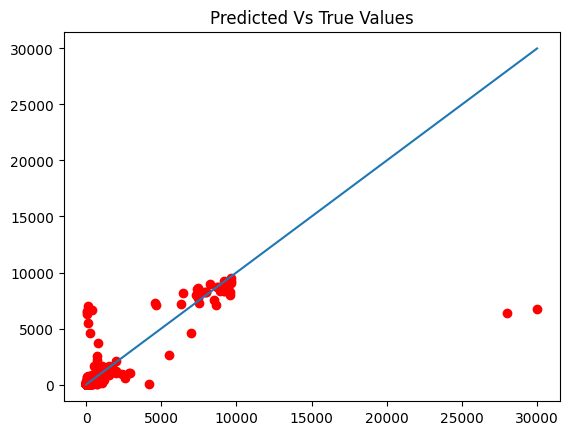

In [25]:
plt.scatter(y_test,y_pred,c='r')
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()])

plt.title('Predicted Vs True Values')

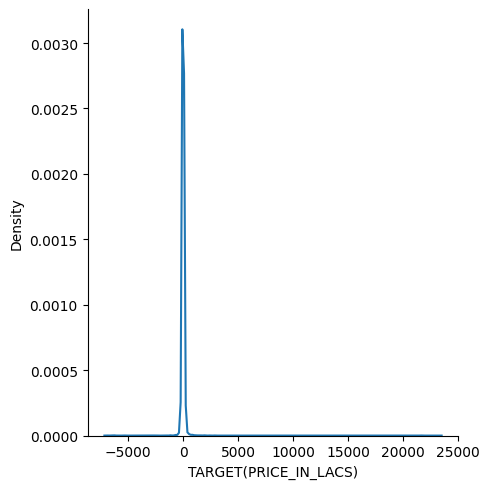

In [26]:
sns.displot(y_test-y_pred,kind='kde')

## Boosting :

### AdaBoost

#### Initialize the model

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(max_depth=10)

ada = AdaBoostRegressor(
    estimator=dtr,
    n_estimators=100,
    learning_rate=0.08,
    random_state=42
)



#### Train the model

In [ ]:
ada.fit(X_train,y_train)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=10),
                  learning_rate=0.08, n_estimators=100, random_state=42)

#### Predict the X_test

In [ ]:
y_pred = ada.predict(X_test)

#### Find MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mae

35.90924177390731

#### Plot the Graph

Text(0, 0.5, 'Predicted Values')

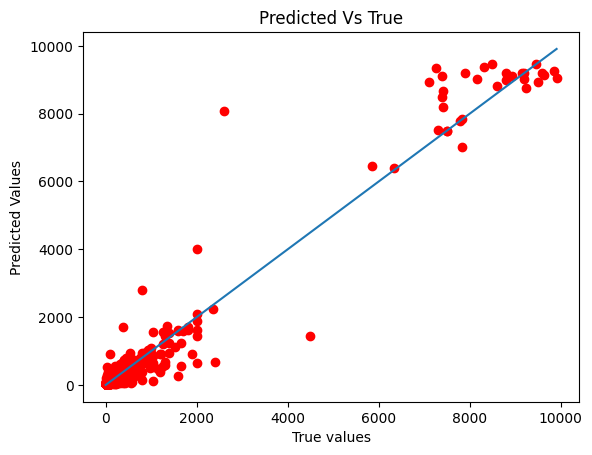

In [ ]:
plt.scatter(y_test,y_pred,c='r')
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()])

plt.title('Predicted Vs True')
plt.xlabel('True values')
plt.ylabel('Predicted Values')

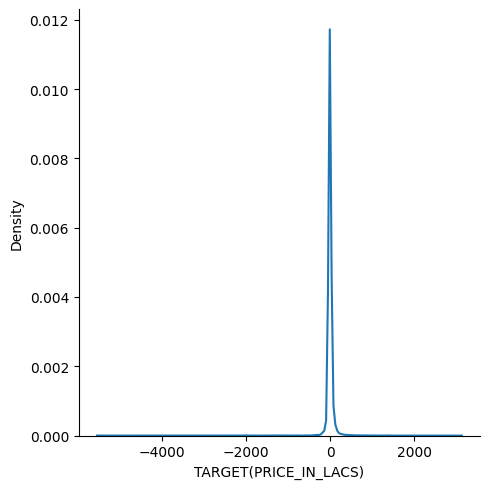

In [ ]:
sns.displot(y_test-y_pred,kind = 'kde')

### Gradient Boost

#### Initialize the model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    loss= 'absolute_error',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8
)

#### Train the model

In [ ]:
gbr.fit(X_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, loss='absolute_error',
                          n_estimators=300, subsample=0.8)

#### Predict the X_test

In [ ]:
y_pred = gbr.predict(X_test)
y_pred

array([26.21805178, 28.5310367 , 54.8096113 , ..., 28.45980238,
       72.37944902, 39.64646816])

#### Find MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mae

40.71626177891145

#### Plot the Graph

Text(0, 0.5, 'Predicted Values')

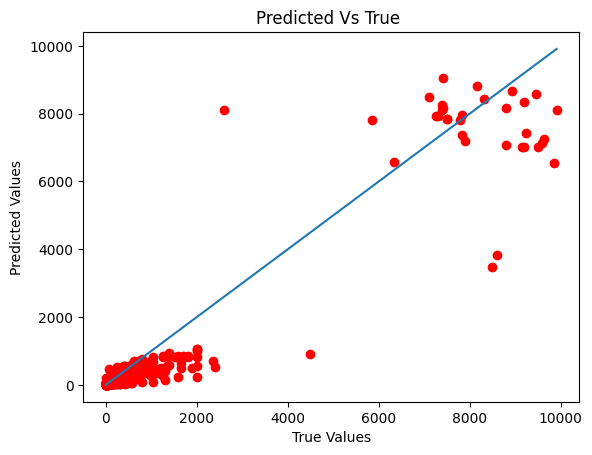

In [ ]:
plt.scatter(y_test,y_pred,c='r')
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()])

plt.title('Predicted Vs True ')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')

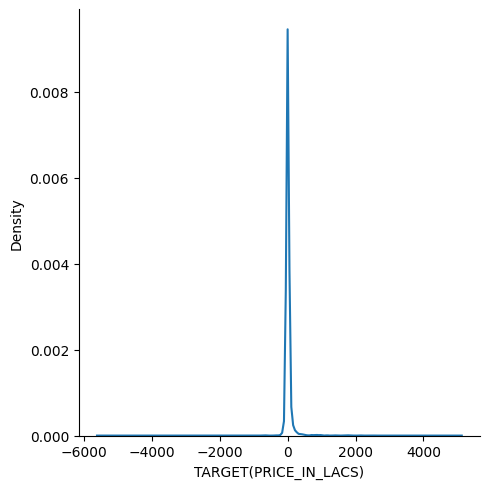

In [ ]:
sns.displot(y_test-y_pred,kind='kde')

### XGBoost ( Extreme Gradient Boost )

#### Initialize and Train the model

In [49]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=10,
    min_child_weight=1,
)


model.fit(X_train,y_train)





XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)


#### Predictions

In [50]:
y_pred = model.predict(X_test)


In [51]:
y_pred

array([ 78.96006 ,  58.128796,  27.71829 , ...,  29.69492 ,  69.62491 ,
       112.55775 ], dtype=float32)



#### Find MAE

In [52]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mae

33.92847800790788

#### Plot the graph

Text(0, 0.5, 'y_pred')

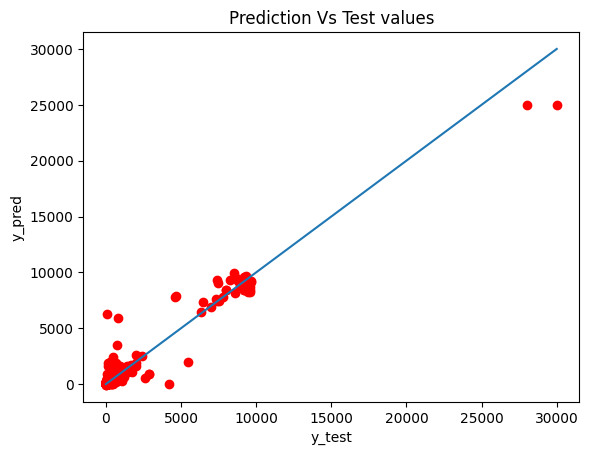

In [53]:
plt.scatter(y_test,y_pred,c='r')
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()])

plt.title('Prediction Vs Test values')
plt.xlabel('y_test')
plt.ylabel('y_pred')


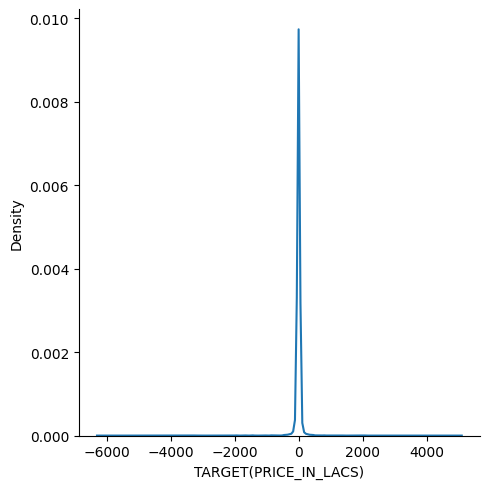

In [54]:
import seaborn as sns

sns.displot(y_test-y_pred,kind='kde')

## *Note : We got the best result by the `XGBoost`*